In [1]:
import sys
import glob
import pickle
import json
import os
import copy
from functools import partial
import random

import numpy as np
import jax.numpy as jnp
import jax.random as jrandom
import jax

sys.path.append('/data/taylor_group/Nima/ATLAS')
sys.path.append('../')
from ATLAS.data import PTA_Data
from ATLAS.pulsar import Pulsar as ATLAS_Pulsar
from ATLAS.model_builder import ModelBuilder
from ATLAS.psd_functions import powerlaw, free_spectrum, hd_orf, gt_orf, bin_orf
from ATLAS.samplers.canetoadracing import model_maker
from ATLAS.samplers.canetoadracing import MultiHMCGibbsWithAnalytic as BlockGibbs
from ATLAS.pulsar import PulsarDataLoader

import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, init_to_value
from tqdm.auto import trange
%load_ext autoreload
%autoreload 2


JAX 64-bit mode automatically enabled successfully.


/home/coronus/miniconda3/envs/atlas/lib/python3.12/site-packages/tqdm_joblib/__init__.py:4: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm
/home/coronus/miniconda3/envs/atlas/lib/python3.12/site-packages/enterprise/signals/utils.py:13: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import Requirement, resource_filename


In [2]:
jax.devices()

[CudaDevice(id=0)]

In [2]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
hist_settings = dict(
    bins = 20,
    histtype = 'step', 
    lw = 3,
    density = True
)

plt.style.use('default')
def figsize(scale, wc = 1, hc = 1):
    fig_width_pt = 513.17 #469.755                  # Get this from LaTeX using \the\textwidth
    inches_per_pt = 1.0/72.27                       # Convert pt to inch
    golden_mean = (np.sqrt(5.0)-1.0)/2.0            # Aesthetic ratio (you could change this)
    fig_width = fig_width_pt*inches_per_pt*scale    # width in inches
    fig_height = fig_width*golden_mean              # height in inches
    fig_size = [wc * fig_width,hc * fig_height]
    return fig_size
plt.rcParams.update(plt.rcParamsDefault)

params = {#'backend': 'pdf',
        'axes.labelsize': 12,
        'lines.markersize': 4,
        'font.size': 10,
        'xtick.major.size':6,
        "xtick.top": True,
        "ytick.right": True,
        "xtick.minor.visible": True,
        "xtick.major.top": True, 
        "xtick.minor.top": True,
        "ytick.minor.visible": True, 
        "ytick.major.right": True, 
        "ytick.minor.right": True,
        "ytick.direction": "in",
        "xtick.direction": "in",
        'xtick.minor.size':3,  
        'ytick.major.size':6,
        'ytick.minor.size':3, 
        'xtick.major.width':0.5,
        'ytick.major.width':0.5,
        'xtick.minor.width':0.5,
        'ytick.minor.width':0.5,
        'lines.markeredgewidth':1,
        'axes.linewidth':1.2,
        'legend.fontsize': 7,
        'xtick.labelsize': 10,
        'ytick.labelsize': 10,
        'savefig.dpi':200,
        'path.simplify':True,
        'font.family': 'serif',
        'font.serif':'Times',
        # "text.usetex": True,
        #'text.latex.preamble': [r'\usepackage{amsmath}'],
        'text.usetex':False,
        'figure.figsize': figsize(0.5, 1, 1)}
plt.rcParams.update(params)
plt.rcParams['font.family'] = 'STIXGeneral'  # Closely matches Computer Modern
plt.rcParams['mathtext.fontset'] = 'stix'    # Use STIX for math

# Loading Data

In [3]:
paths = sorted(glob.glob('/home/koonima/ATLAS/datasets/NG15/ATLAS_pulsar/*.npz'))
psrs = []
for path in paths:
    psrs.append(PulsarDataLoader(**np.load(path)))
len(psrs)

67

### The ATLAS `data` object completes the data loading process. You assign your general data analysis settings now, and eveything else will inherit these.

In [4]:
with open('../datasets/NG15/v1p1_wn_dict.json', 'r') as fin:
    noise_dict = json.load(fin)

In [5]:
data = PTA_Data(psrs, 
                num_gwb_bins = 14, # if you do not want to have a GWB, you can ignore this
                num_irn_bins = 30, # irn is pulsar noise. NOTE: This is achromatic noise

                linear_timing = True, # do you want to model timing model errors as linear?
                marg_timing = True, # do you want to marginalize out linear timing model errors?

                noise_dict = noise_dict, #do you have a white noise dictionary
                )

In [6]:
m = ModelBuilder(data = data)

## White Noise

In [7]:
wn = m.make_white_noise(stabilize_TNT = False) # stabilize_TNT is a MUST if you are doing single precision
wn_lower_bound, wn_upper_bound = wn.get_prior_bounds()

Constructing the white noise cov matrix for B1855+09:   0%|          | 0/67 [00:00<?, ?it/s]

Constructing the white noise cov matrix for J2322+2057: 100%|██████████| 67/67 [00:46<00:00,  1.43it/s]


## Red Noise

In [8]:
basis_string = "unc+cor->unc"

## Understanding `basis_string`

The `basis_string` is a compact way to tell the software **how different signals should be organized into basis matrices**.

The general form is:

    [timing model] | [signals sharing a basis] -> [basis to use] ; [separate signals]

Each part is optional depending on the desired configuration.

### 1. Signals can have separate bases

Suppose your model contains signals named `unc`, `cor`, `dm`, and `cw`.

Signals listed after `;` are treated as **separate bases**.

For example:

    unc ; cor

means that `unc` and `cor` are all treated separately. There is no shared basis in this example.

### 2. Signals can share a basis

The syntax

    unc+cor->unc

means:

> `unc` and `cor` share one basis, and the basis associated with `unc` is used as the representative basis.

Breaking this down:

    unc + cor -> unc
     │     │       │
     │     │       └── use unc's basis
     │     └────────── cor belongs to the shared group
     └──────────────── unc belongs to the shared group

The signal after `->` must be one of the signals listed before the arrow.

For example,

    unc+cor->cor

means that `unc` and `cor` still share a basis, but now `cor` provides the representative basis.

****NOTE****: signals sharing bases does not mean same number of frequencies. It means that one basis contains the other.

### 3. Adding the timing-model basis

Putting

    ltm|

at the beginning tells the software to also include the pulsar's **linear timing-model basis (M-matrix)**.

For example,

    unc+cor->unc

does **not** include the timing-model basis, while

    ltm|unc+cor->unc

uses the same shared basis configuration **and** includes the timing-model M-matrix.


### 4. Combining shared and separate bases

A more complete example is:

    ltm|unc+cor->unc ; cw

Read this from left to right as:

1. `ltm|` — include the linear timing-model M-matrix.
2. `unc+cor` — `unc` and `cor` belong to a shared basis group.
3. `->unc` — use `unc` as the representative basis for that group.
4. `; cw` — keep `cw` as a separate basis.

Conceptually:

    ltm | unc + cor -> unc ; cw
     │      │    │      │     │
     │      └────┴──────┘     └── separate basis
     │       shared basis
     │       represented by unc
     │
     └── include timing-model M-matrix

### Examples

| `basis_string` | Meaning |
|---|---|
| `unc+cor->unc` | `unc` and `cor` share a basis; use `unc`'s basis |
| `ltm\|unc+cor->unc` | Same as above, plus the timing-model M-matrix |
| `ltm\|unc+cor->unc ; cw` | Timing model + shared `unc/cor` basis + separate `cw` basis |
| `unc ; cor,dm` | `unc`, `cor`, and `dm` all have separate bases |
| `ltm\|unc ; cor,dm` | Same as above, plus the timing-model M-matrix |

### Quick reference

- `ltm|` → include the linear timing-model (M-matrix) basis
- `+` → signals belong to the same shared basis
- `->` → choose which signal provides the representative basis
- `;` → separate the shared/main group from signals with independent bases
- `,` → separate multiple independent signals

For example:

    ltm|unc+cor->unc ; cw,dm

means:

> Include the timing-model M-matrix; let `unc` and `cor` share the basis provided by `unc`; and keep `cw` and `dm` as separate bases.

In [9]:
rn = m.make_red_noise(basis_string,
                use_pulsar_tspan = False, #should non-gwb pulsar noise have Tpsan based on each individual pulsar?
                irn_psd_function = partial(powerlaw), # PSD function
                gwb_psd_function = partial(powerlaw), #PSD function
                orf_function = hd_orf, #ORF function

                irn_lower_bound_psd = jnp.array([-18, 0.]), #the order must match what is accepted by the PSD function
                irn_upper_bound_psd = jnp.array([-11, 7.]), #the order must match what is accepted by the PSD function
               
                gwb_lower_bound_psd = jnp.array([-18, 0]), #the order must match what is accepted by the PSD function
                gwb_upper_bound_psd = jnp.array([-11, 7]), #the order must match what is accepted by the PSD function

                 )

In [10]:
helpers = rn.get_helpers(reff = jnp.concat(data.raw_residuals), #reff is the effective residuals. It can be the actual `true` residuals
                                                                # or be model-subtracted residuals for Block Gibbs sampling
                white_noise_params = wn.params_dict_to_vector(data.noise_dict)
                )

E0917 00:37:09.973324   18124 slow_operation_alarm.cc:73] Constant folding an instruction is taking > 1s:

  %gather.4508 = f64[88680,1,423]{2,1,0} gather(%constant.3235, %constant.11871), offset_dims={1,2}, collapsed_slice_dims={}, start_index_map={0}, index_vector_dim=1, slice_sizes={1,423}, metadata={op_name="jit(<unknown>)/jit(<unknown>)/gather" stack_frame_id=69}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
E0917 00:37:10.110185   17961 slow_operation_alarm.cc:140] The operation took 1.136957614s
Constant folding an instruction is taking > 1s:

  %gather.4508 = f64[88680,1,423]{2,1,0} gather(%constant.3235, %constant.11871), offset

In [11]:
## This is TNT: helpers[0]
## This is TNr: helpers[1]
## This is rNr: helpers[2]
## This is logdetN: helpers[3]

### Let's sample all together!

In [12]:
nuts_kernel = NUTS(
            model = model_maker,
            target_accept_prob = 0.8,
            max_tree_depth = 10)
mcmc = MCMC(
    sampler=nuts_kernel,
    num_warmup=500,
    num_samples=3000,
    num_chains=1,
)
mcmc.run(jrandom.key(170817), 
                extra_fields=("~z.z_a",), #no need to save the auxilary coefficients
                raw_residuals = jnp.concat(data.raw_residuals), # the true residuals
                super_sig = rn, #the signal with the liklelihood calls
                vary_white = False,
                helpers = helpers,
                save_red_coeff = False, #do you want to save the coefficients?
                marg_over_non_gwb = False)

sample: 100%|██████████| 3500/3500 [28:45<00:00,  2.03it/s, 127 steps of size 4.52e-02. acc. prob=0.94] 


In [13]:
samps = mcmc.get_samples()

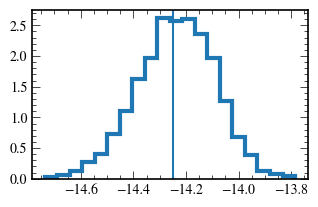

In [17]:
plt.hist(samps['red_noise'][:, -2], **hist_settings)
plt.axvline(-14.25)
plt.show()

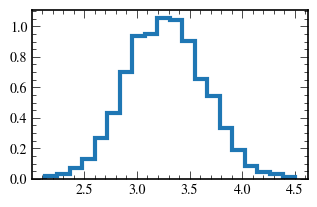

In [16]:
plt.hist(samps['red_noise'][:, -1], **hist_settings)
plt.show()